## Data Collection & Understanding

### DATASET DETAILS<br>
Selected 150 Colleges<br>
IDs assigned for merging data from different sources.<br>
<br>

#### Sources
1. CollegeDunia - collegedunia.csv (1500) [Scroll Based Web Scrapping]
2. Careers360 - careers360.csv (11368) [Paginated Web Scrapping through iterations]
3. Kaggle - kaggle.csv (4307) [Just downloaded and merged 2021, 2022, 2023 data]

In [3]:
import pandas as pd
from IPython.display import display
# Load Datasets

collegedunia = pd.read_csv("collegedunia.csv", encoding="latin1")
careers360 = pd.read_csv("careers360.csv", encoding="latin1")
kaggle = pd.read_csv("kaggle.csv", encoding="latin1")


def dataset_summary(name, df):
    print(f"\n==============================")
    print(f"{name} Dataset")
    print(f"==============================")
    
    print("\nFirst 5 Rows:")
    display(df.head())
    
    print("\nColumn Names:")
    print(list(df.columns))
    
    print("\nNumber of Rows:", df.shape[0])
    print("Number of Columns:", df.shape[1])

# Summary of Each Dataset

dataset_summary("CollegeDunia", collegedunia)
dataset_summary("Careers360", careers360)
dataset_summary("Kaggle", kaggle)



CollegeDunia Dataset

First 5 Rows:


,ï»¿college_id,college_name,review_title,overall_rating,review_text,posted_info,source,page_number
0,1,IIT Bombay - Indian Institute of Technology - ...,The Life at the most prestigious Instititute (...,4.1,Pros/Cons: The students team here in IIT BOMBA...,"Reviewed on Sep 9, 2025",CollegeDunia,1
1,1,IIT Bombay - Indian Institute of Technology - ...,HONEST AND REFLECTIVE,4.3Helpful,Pros/Cons: professor are knowlegeable and supp...,"Reviewed on Jul 19, 2025",CollegeDunia,1
2,1,IIT Bombay - Indian Institute of Technology - ...,All aspect of IITB sumarised,4.8Helpful,"Pros/Cons: So many events, no only fests but c...","Reviewed on Mar 13, 2025",CollegeDunia,1
3,1,IIT Bombay - Indian Institute of Technology - ...,IIT Bombay insider view,4.4Helpful,Pros/Cons: This is the top most IIT which prov...,"Reviewed on Mar 10, 2025",CollegeDunia,1
4,1,IIT Bombay - Indian Institute of Technology - ...,Life at IIT Bombay : In and Out,3.6Helpful,Pros/Cons: The boys to girls ratio is now 4:1 ...,"Reviewed on Feb 22, 2025",CollegeDunia,1



Column Names:
['ï»¿college_id', 'college_name', 'review_title', 'overall_rating', 'review_text', 'posted_info', 'source', 'page_number']

Number of Rows: 1460
Number of Columns: 8

Careers360 Dataset

First 5 Rows:


,college_id,college_name,review_title,overall_rating,review_text,posted_info,source,page_number
0,95,Amity University Noida,Best infrastructure and faculty in Amity Unive...,5.0,[College Infrastructure]: Amity offers world-c...,Posted on 19 Dec '25 by DeepuBatch of 2025-01-...,careers360,1
1,141,DIT University Dehradun,My experience at DIT University has been mostl...,3.6,[College Infrastructure]: College infrastructu...,Posted on 19 Dec '25 by AnonymousThis user cho...,careers360,1
2,141,DIT University Dehradun,"Good academics, average placements, enjoyable ...",3.4,[College Infrastructure]: The college infrastr...,Posted on 19 Dec '25 by AnonymousThis user cho...,careers360,1
3,141,DIT University Dehradun,It's a wonderful college to be honest.,4.0,[College Infrastructure]: DIT University boast...,Posted on 19 Dec '25 by SujalBatch of 2029-01-...,careers360,1
4,141,DIT University Dehradun,Average,3.0,[College Infrastructure]: The infrastructure o...,Posted on 19 Dec '25 by AnonymousThis user cho...,careers360,1



Column Names:
['college_id', 'college_name', 'review_title', 'overall_rating', 'review_text', 'posted_info', 'source', 'page_number']

Number of Rows: 11368
Number of Columns: 8

Kaggle Dataset

First 5 Rows:


,college_id,college_name,review_text,rating,source_year,source,review_id
0,119,Galgotias University - [GU],The civil department is very good in this coll...,3.10,2021,kaggle,4
1,118,Heritage Institute of Technology - [HIT],The name of the annual fest is Eclecia and the...,3.85,2021,kaggle,25
2,84,Vellore Institute of Technology - [VIT],The fee structure is decided based on our Rank...,4.35,2021,kaggle,28
3,96,Kalinga Institute of Industrial Technology - [...,KIIT provides internships from the sixth semes...,4.25,2021,kaggle,93
4,36,National Institute of Technology - [NITP],"College is very good from every point of view,...",4.40,2021,kaggle,97



Column Names:
['college_id', 'college_name', 'review_text', 'rating', 'source_year', 'source', 'review_id']

Number of Rows: 4307
Number of Columns: 7


## Problem Understanding & Objective Definition

### Problem Statement:

Student reviews across platforms such as CollegeDunia, Careers360, and Kaggle contain valuable insights about institutional quality and student satisfaction. However, these reviews are fragmented, vary in format, and include both structured ratings and unstructured text.
<br><br>
The problem addressed in this project is to integrate multi-source review data and analyze student perception of engineering colleges using both numerical ratings and textual sentiment.
<br>

### Objectives:
1. To merge and standardize review datasets from multiple sources.
2. To clean and preprocess textual and numerical data.
3. To analyze rating distributions across colleges and platforms.
4. To perform sentiment analysis on review text.
5. To evaluate the impact of key topics such as placements, faculty, and infrastructure on ratings.
6. To visualize institutional perception using advanced exploratory data analysis techniques.

### Assumptions:
1. Student reviews represent genuine experiences.
2. Normalized ratings across platforms are comparable.
3. Sentiment analysis accurately captures emotional tone.
4. Topic mentions reflect important aspects influencing ratings.

## Data Preparation / Data Preprocessing

# Data Cleaning: Missing values, outliers, inconsistencies handled
Date Format
Rating hidden in text
Missing Values

# Feature Engineering: Meaningful features with justification
Sentiment Score (VADER)
Rating_category
Review_text_length
sentiment_label

# Data Transformation: Correct scaling, encoding, normalization
Scaling of rating to 5 from 10
Weighted avg rating for better variance

In [4]:
# Fix BOM column issue
collegedunia.rename(columns={"ï»¿college_id": "college_id"}, inplace=True)


CollegeDunia Problem:<br>
Values like:<br>
4.3Helpful<br>
4.8Helpful<br>

In [5]:
import re

# Extract numeric rating
collegedunia["overall_rating"] = collegedunia["overall_rating"].astype(str)

collegedunia["overall_rating"] = collegedunia["overall_rating"].str.extract(r"(\d+\.?\d*)")

collegedunia["overall_rating"] = collegedunia["overall_rating"].astype(float)


CollegeDunia example:
"Reviewed on Sep 9, 2025"

Careers360 example:
"Posted on 19 Dec '25 by ..."

In [6]:
# CollegeDunia date extraction
collegedunia["date"] = collegedunia["posted_info"].str.extract(r"Reviewed on (.*)")
collegedunia["date"] = pd.to_datetime(collegedunia["date"], errors="coerce")

# Careers360 date extraction
careers360["date"] = careers360["posted_info"].str.extract(r"Posted on (.*?) by")
careers360["date"] = pd.to_datetime(careers360["date"], errors="coerce")


C:\Users\grove\AppData\Local\Temp\ipykernel_11368\2094954900.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  careers360["date"] = pd.to_datetime(careers360["date"], errors="coerce")


In [8]:
#for kaggle, we only have the year
kaggle["date"] = pd.to_datetime(kaggle["source_year"], format="%Y", errors="coerce")


In [7]:
#standardizing rating column name and scale
# CollegeDunia
collegedunia["rating"] = collegedunia["overall_rating"]

# Careers360
careers360["rating"] = careers360["overall_rating"]

# Kaggle already scaled
# rating column already exists


In [9]:
collegedunia_final = collegedunia[[
    "college_id",
    "college_name",
    "review_text",
    "rating",
    "date",
    "source"
]].copy()

careers360_final = careers360[[
    "college_id",
    "college_name",
    "review_text",
    "rating",
    "date",
    "source"
]].copy()

kaggle_final = kaggle[[
    "college_id",
    "college_name",
    "review_text",
    "rating",
    "date",
    "source"
]].copy()


In [10]:
combined = pd.concat(
    [collegedunia_final, careers360_final, kaggle_final],
    ignore_index=True
)


In [11]:
#Remove missing review_text
combined.dropna(subset=["review_text"], inplace=True)


In [12]:
#Remove missing ratings
combined.dropna(subset=["rating"], inplace=True)
#Remove rating outliers
combined = combined[(combined["rating"] >= 0) & (combined["rating"] <= 5)]
# Clean text
import string

combined["review_text"] = combined["review_text"].str.lower()
combined["review_text"] = combined["review_text"].str.replace(r"\n", " ", regex=True)
combined["review_text"] = combined["review_text"].str.replace(r"\s+", " ", regex=True)
combined["review_text"] = combined["review_text"].str.strip()


In [13]:
# create review_id
combined.reset_index(inplace=True)
combined.rename(columns={"index": "review_id"}, inplace=True)


In [14]:
print("Final Dataset Shape:", combined.shape)
combined.head()


Final Dataset Shape: (17131, 7)


,review_id,college_id,college_name,review_text,rating,date,source
0,0,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: the students team here in iit bomba...,4.1,2025-09-09,CollegeDunia
1,1,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: professor are knowlegeable and supp...,4.3,2025-07-19,CollegeDunia
2,2,1,IIT Bombay - Indian Institute of Technology - ...,"pros/cons: so many events, no only fests but c...",4.8,2025-03-13,CollegeDunia
3,3,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: this is the top most iit which prov...,4.4,2025-03-10,CollegeDunia
4,4,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: the boys to girls ratio is now 4:1 ...,3.6,2025-02-22,CollegeDunia


In [15]:
combined["review_length"] = combined["review_text"].apply(lambda x: len(str(x).split()))
print("Average Review Length (in words):", combined["review_length"].mean())

Average Review Length (in words): 162.78641060066545


In [17]:
def rating_bucket(x):
    if x <= 2:
        return "Low"
    elif x <= 4:
        return "Medium"
    else:
        return "High"

combined["rating_category"] = combined["rating"].apply(rating_bucket)
print("Rating Category Distribution:")
print(combined["rating_category"].value_counts())



Rating Category Distribution:
rating_category
High      10500
Medium     6568
Low          63
Name: count, dtype: int64


In [18]:
combined["year"] = combined["date"].dt.year
print("Reviews per Year:")
print(combined["year"].value_counts().sort_index())


Reviews per Year:
year
2020       7
2021    2560
2022    1372
2023    6964
2024    3588
2025    2640
Name: count, dtype: int64


VADER (Valence Aware Dictionary for Sentiment Reasoning).<br>
It is a rule-based sentiment analysis tool built for social text.<br>

What VADER Returns<br>

For each review, it gives:<br>
1. positive score<br>
2. negative score<br>
3. neutral score<br>
4. compound score<br>

Example:<br>
analyzer.polarity_scores("This college is amazing and placements are great")<br>
Output:<br>
{
 'neg': 0.0,
 'neu': 0.45,
 'pos': 0.55,
 'compound': 0.87
}<br>

Compound score is:<br>
A normalized score between -1 and +1<br>
Overall sentiment of the sentence<br>
<br>
Then converted it to labels:<br>
score >= 0.05 → Positive<br>
score <= -0.05 → Negative<br>
otherwise → Neutral<br>
<br>
Thus, got numerical data from long text.<br>

In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    return score["compound"]

combined["sentiment_score"] = combined["review_text"].apply(get_sentiment)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Sentiment Score Distribution:
count    17131.000000
mean         0.882127
std          0.263710
min         -0.992500
25%          0.912300
50%          0.967900
75%          0.986100
max          0.999800
Name: sentiment_score, dtype: float64


In [20]:
print("Sentiment Score Distribution:")
print(combined["sentiment_score"].describe())

Sentiment Score Distribution:
count    17131.000000
mean         0.882127
std          0.263710
min         -0.992500
25%          0.912300
50%          0.967900
75%          0.986100
max          0.999800
Name: sentiment_score, dtype: float64


In [22]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

combined["sentiment_label"] = combined["sentiment_score"].apply(sentiment_label)
print("Sentiment Label Distribution:")
print(combined["sentiment_label"].value_counts())



Sentiment Label Distribution:
sentiment_label
Positive    16650
Negative      397
Neutral        84
Name: count, dtype: int64


# EDA Level 1

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


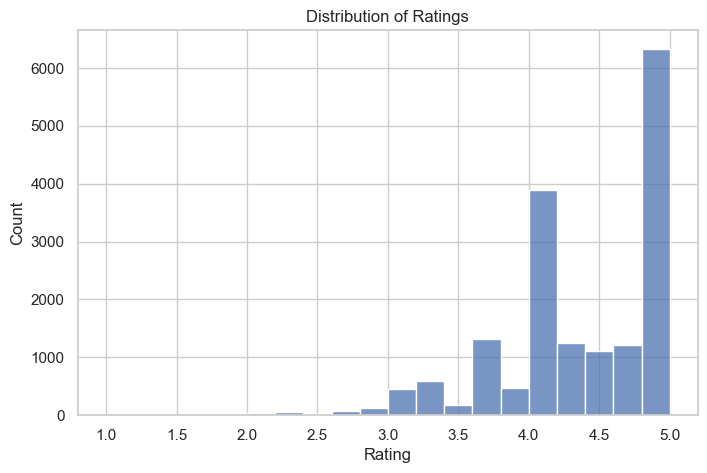

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(combined["rating"], bins=20)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


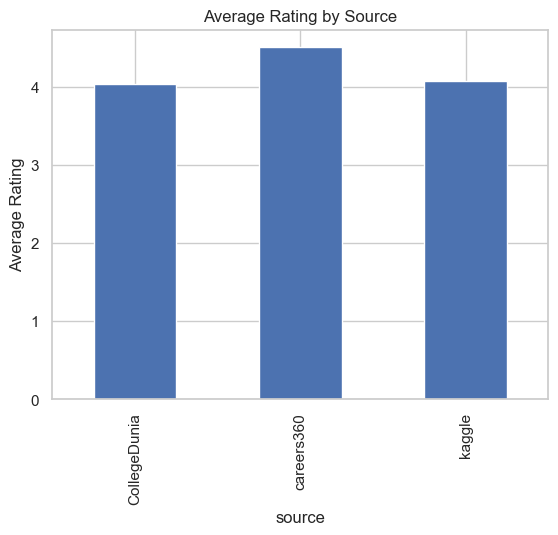

In [44]:
combined.groupby("source")["rating"].mean().plot(kind="bar")
plt.title("Average Rating by Source")
plt.ylabel("Average Rating")
plt.show()


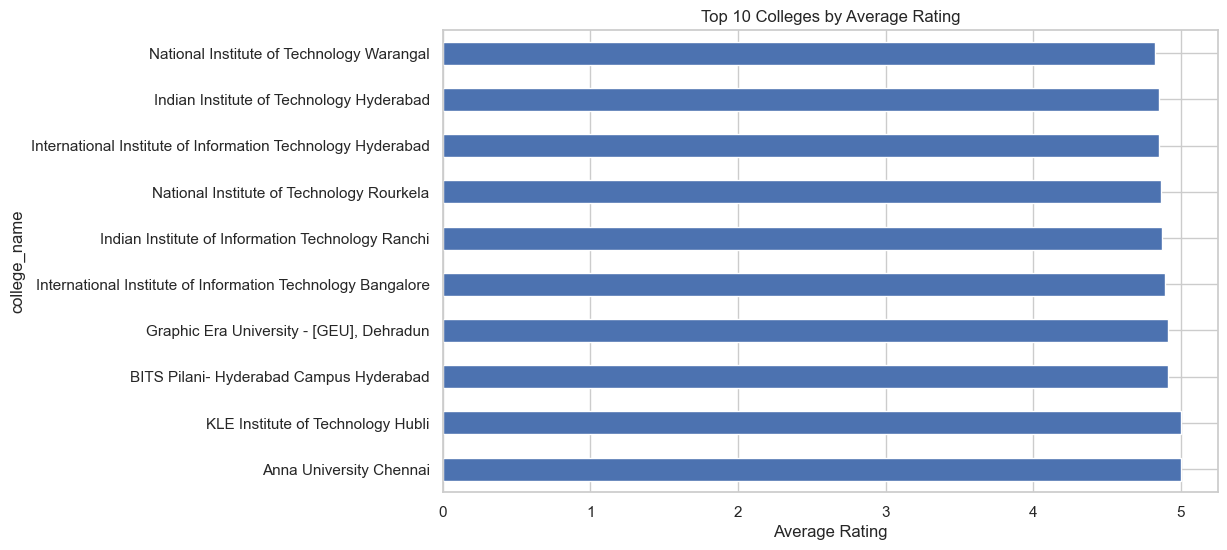

In [45]:
top10 = (
    combined.groupby("college_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top10.plot(kind="barh")
plt.title("Top 10 Colleges by Average Rating")
plt.xlabel("Average Rating")
plt.show()


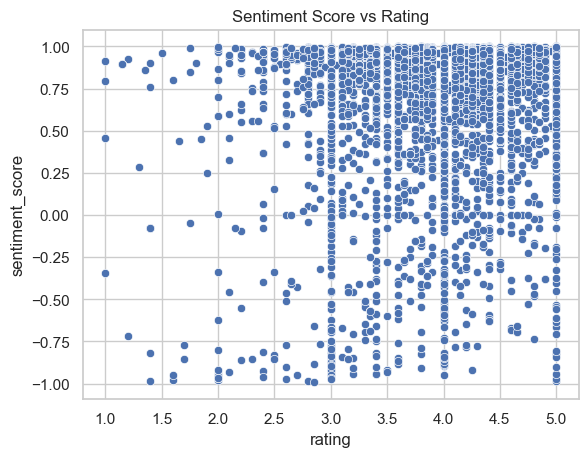

Correlation: 0.274617214143536


In [46]:
sns.scatterplot(x="rating", y="sentiment_score", data=combined)
plt.title("Sentiment Score vs Rating")
plt.show()

print("Correlation:", combined["rating"].corr(combined["sentiment_score"]))


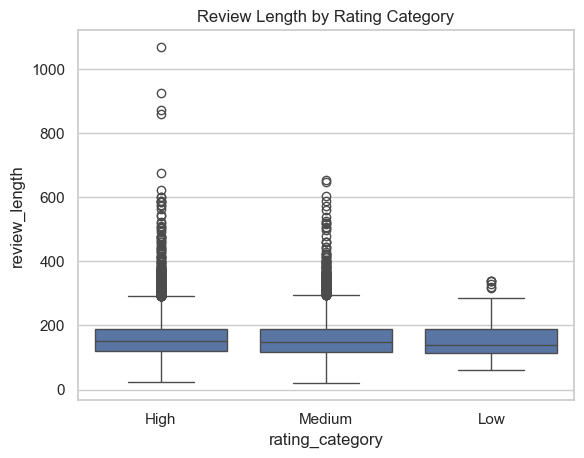

In [47]:
sns.boxplot(x="rating_category", y="review_length", data=combined)
plt.title("Review Length by Rating Category")
plt.show()


In [48]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


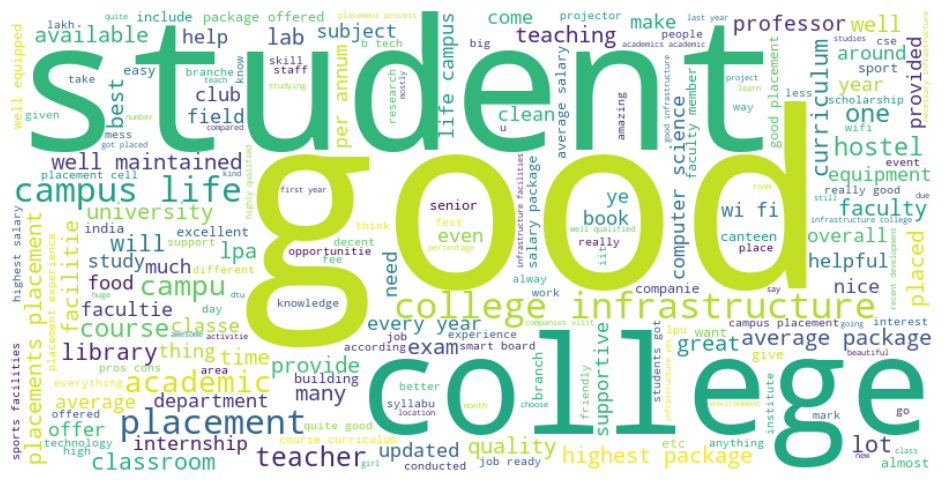

In [49]:

from wordcloud import WordCloud

text = " ".join(combined["review_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [50]:
dataset_summary("Combined", combined)



Combined Dataset

First 5 Rows:


,review_id,college_id,college_name,review_text,rating,date,source,review_length,rating_category,year,sentiment_score,sentiment_label
0,0,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: the students team here in iit bomba...,4.1,2025-09-09,CollegeDunia,138,High,2025,0.9720,Positive
1,1,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: professor are knowlegeable and supp...,4.3,2025-07-19,CollegeDunia,120,High,2025,0.9545,Positive
2,2,1,IIT Bombay - Indian Institute of Technology - ...,"pros/cons: so many events, no only fests but c...",4.8,2025-03-13,CollegeDunia,156,High,2025,0.9677,Positive
3,3,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: this is the top most iit which prov...,4.4,2025-03-10,CollegeDunia,110,High,2025,-0.1374,Negative
4,4,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: the boys to girls ratio is now 4:1 ...,3.6,2025-02-22,CollegeDunia,180,Medium,2025,0.8906,Positive



Column Names:
['review_id', 'college_id', 'college_name', 'review_text', 'rating', 'date', 'source', 'review_length', 'rating_category', 'year', 'sentiment_score', 'sentiment_label']

Number of Rows: 17131
Number of Columns: 12



College Name: IIT Ropar - Indian Institute of Technology - [IITR], Ropar
Total Reviews: 38


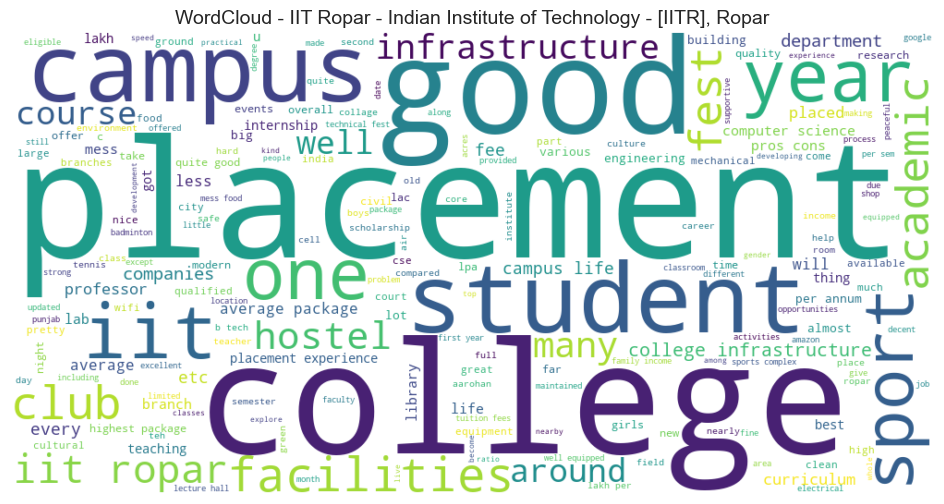

In [52]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

def generate_college_wordcloud(college_id_input):
    
    # Filter data
    college_data = combined[combined["college_id"] == college_id_input]
    
    if college_data.empty:
        print("No data found for this college_id")
        return
    
    # Get college name
    college_name = college_data["college_name"].iloc[0]
    
    print(f"\nCollege Name: {college_name}")
    print(f"Total Reviews: {len(college_data)}")
    
    # Combine review text
    text = " ".join(college_data["review_text"].dropna())
    
    # Stopwords
    stopwords = set(STOPWORDS)
    
    # Generate WordCloud
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        stopwords=stopwords,
        max_words=200
    ).generate(text)
    
    # Plot
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - {college_name}", fontsize=14)
    plt.show()

# Take Input
college_id_input = int(input("Enter College ID: "))
generate_college_wordcloud(college_id_input)


# EDA Level 2

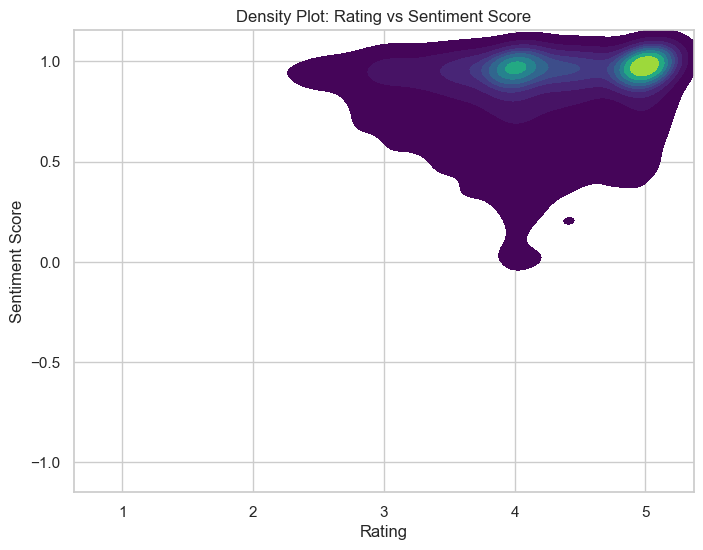

In [ ]:
# Rating vs Sentiment Heatmap
# Shows whether numeric ratings actually match emotional tone.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.kdeplot(
    x=combined["rating"],
    y=combined["sentiment_score"],
    cmap="viridis",
    fill=True
)
plt.title("Density Plot: Rating vs Sentiment Score")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.show()


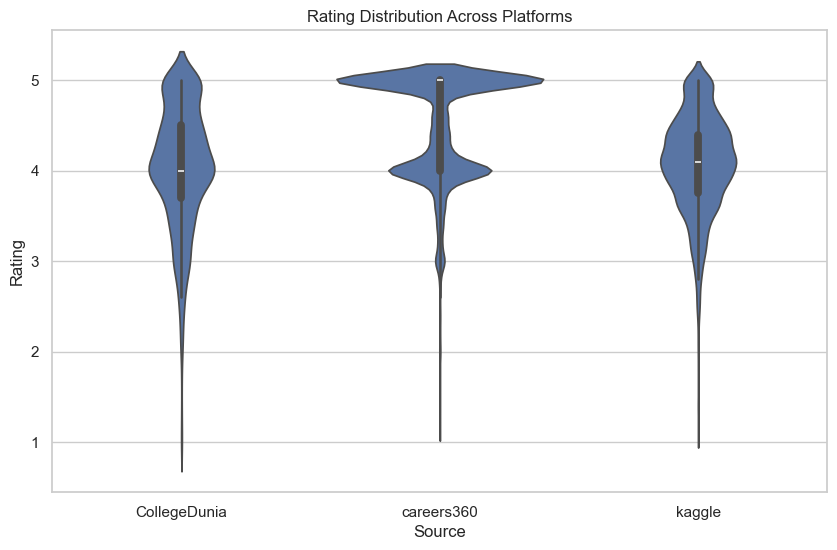

In [54]:
plt.figure(figsize=(10,6))
sns.violinplot(x="source", y="rating", data=combined)
plt.title("Rating Distribution Across Platforms")
plt.xlabel("Source")
plt.ylabel("Rating")
plt.show()


Interpretation:<br>
Wider violin = more variance<br>
Higher median = positive bias<br>

The violin plot shows that Careers360 has the highest concentration of ratings near 5, indicating a strong positive bias or more satisfied reviewers. CollegeDunia and Kaggle show a wider spread of ratings, especially in the 3 to 4 range, suggesting more varied student experiences. Kaggle exhibits slightly more lower-end ratings compared to Careers360, indicating relatively more critical feedback. Overall, Careers360 appears to have the most positively skewed rating distribution among the three platforms.

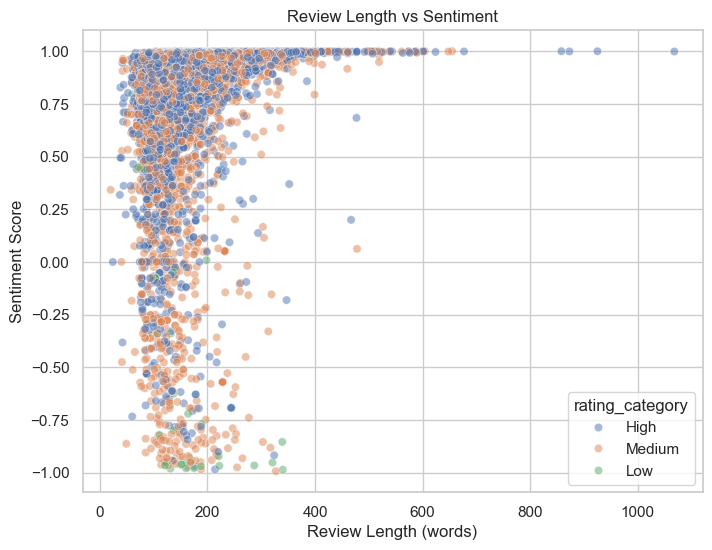

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="review_length",
    y="sentiment_score",
    hue="rating_category",
    data=combined,
    alpha=0.5
)
plt.title("Review Length vs Sentiment")
plt.xlabel("Review Length (words)")
plt.ylabel("Sentiment Score")
plt.show()


In [62]:
from collections import Counter
from wordcloud import STOPWORDS
import re

stopwords = set(STOPWORDS)

def top_words_clean(df, label):
    
    text = " ".join(df[df["rating_category"] == label]["review_text"])
    
    # Remove non-letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    words = text.split()
    
    # Remove stopwords + small words
    words = [
        word for word in words 
        if word not in stopwords and len(word) > 3
    ]
    
    return Counter(words).most_common(15)

print("Low Rating Words:", top_words_clean(combined, "Low"))
print("High Rating Words:", top_words_clean(combined, "High"))


Low Rating Words: [('college', 173), ('good', 120), ('campus', 110), ('students', 108), ('placements', 87), ('placement', 61), ('infrastructure', 56), ('life', 50), ('dont', 43), ('teachers', 41), ('academics', 39), ('year', 34), ('will', 33), ('average', 28), ('student', 27)]
High Rating Words: [('college', 26109), ('good', 20886), ('campus', 18573), ('students', 17645), ('placements', 14291), ('infrastructure', 13628), ('placement', 10743), ('academics', 9443), ('life', 8785), ('well', 8348), ('facilities', 6405), ('many', 6341), ('package', 6291), ('year', 5923), ('companies', 5760)]



College Name: IIT Delhi - Indian Institute of Technology [IITD], New Delhi
Total Reviews: 340


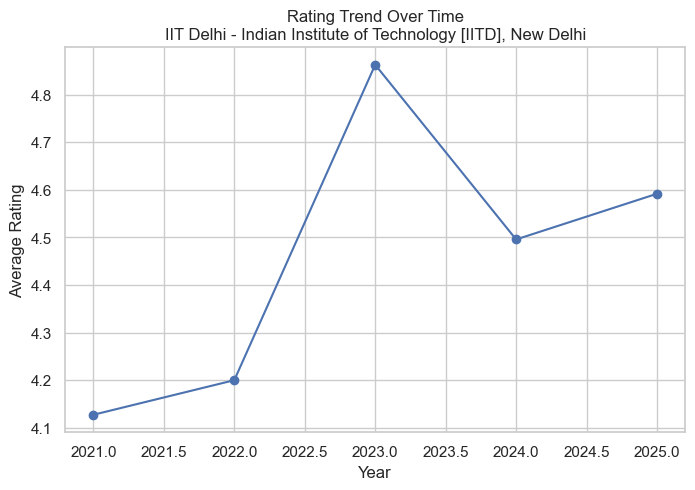

In [64]:
import matplotlib.pyplot as plt

def rating_trend_by_college(college_id_input):
    
    college_data = combined[combined["college_id"] == college_id_input]
    
    if college_data.empty:
        print("No data found for this college_id")
        return
    
    college_name = college_data["college_name"].iloc[0]
    
    print(f"\nCollege Name: {college_name}")
    print(f"Total Reviews: {len(college_data)}")
    
    # Group by year
    trend = college_data.groupby("year")["rating"].mean()
    
    if len(trend) < 2:
        print("Not enough yearly data to show trend.")
        return
    
    plt.figure(figsize=(8,5))
    plt.plot(trend.index, trend.values, marker="o")
    plt.title(f"Rating Trend Over Time\n{college_name}")
    plt.xlabel("Year")
    plt.ylabel("Average Rating")
    plt.grid(True)
    plt.show()

# Take input
college_id_input = int(input("Enter College ID: "))
rating_trend_by_college(college_id_input)


# EDA Level 3

In [66]:
!pip install plotly


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
import plotly.express as px

# Prepare data (same as before)
college_insights = (
    combined
    .groupby("college_name")
    .agg(
        avg_rating=("rating", "mean"),
        sentiment_std=("sentiment_score", "std"),
        review_count=("review_id", "count")
    )
    .dropna()
    .reset_index()
)

college_insights["sentiment_consistency"] = 1 / (1 + college_insights["sentiment_std"])

# Interactive Bubble Plot
fig = px.scatter(
    college_insights,
    x="avg_rating",
    y="sentiment_consistency",
    size="review_count",
    hover_name="college_name",   # <-- College name appears
    hover_data={
        "avg_rating": True,
        "review_count": True,
        "sentiment_consistency": True
    },
    size_max=60,
    title="Interactive College Perception Map"
)

fig.update_layout(
    xaxis_title="Average Rating",
    yaxis_title="Sentiment Consistency"
)

fig.show()


In [71]:
keywords = ["placement", "faculty", "infrastructure", "hostel", "campus"]

for word in keywords:
    combined[word] = combined["review_text"].str.contains(word, regex=False)
topic_data = []

for word in keywords:
    avg_rating = combined[combined[word] == True]["rating"].mean()
    count = combined[combined[word] == True]["review_id"].count()
    
    topic_data.append({
        "Topic": word,
        "Average Rating": avg_rating,
        "Mentions": count
    })

import pandas as pd
topic_df = pd.DataFrame(topic_data)
import plotly.express as px

fig = px.bar(
    topic_df,
    x="Topic",
    y="Average Rating",
    color="Average Rating",
    color_continuous_scale="Viridis",
    hover_data=["Mentions"],
    title="Impact of Topics on Average Rating"
)

fig.update_layout(
    xaxis_title="Topic Mentioned in Review",
    yaxis_title="Average Rating",
    coloraxis_colorbar=dict(title="Avg Rating")
)

fig.show()


In [72]:
source_variance = combined.groupby("source")["rating"].var().reset_index()
source_variance.columns = ["source", "variance"]

print(source_variance)
source_variance["weight"] = source_variance["variance"] / source_variance["variance"].sum()

print(source_variance)
combined = combined.merge(
    source_variance[["source", "weight"]],
    on="source",
    how="left"
)
comparison_data = []

for word in keywords:
    
    df_yes = combined[combined[word] == True]
    df_no = combined[combined[word] == False]
    
    weighted_yes = (df_yes["rating"] * df_yes["weight"]).sum() / df_yes["weight"].sum()
    weighted_no = (df_no["rating"] * df_no["weight"]).sum() / df_no["weight"].sum()
    
    comparison_data.append({
        "Topic": word,
        "Mentioned (Weighted)": weighted_yes,
        "Not Mentioned (Weighted)": weighted_no
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df_melted = comparison_df.melt(
    id_vars="Topic",
    var_name="Condition",
    value_name="Weighted Average Rating"
)

import plotly.express as px

fig = px.bar(
    comparison_df_melted,
    x="Topic",
    y="Weighted Average Rating",
    color="Condition",
    barmode="group",
    title="Weighted Impact of Topic Mention on Ratings"
)

fig.update_layout(
    xaxis_title="Topic",
    yaxis_title="Weighted Average Rating"
)

fig.show()


         source  variance
0  CollegeDunia  0.472291
1    careers360  0.350135
2        kaggle  0.308461
         source  variance    weight
0  CollegeDunia  0.472291  0.417629
1    careers360  0.350135  0.309611
2        kaggle  0.308461  0.272760


Blue bars represent the weighted average rating when a particular topic is mentioned in the review.<br>
Red bars represent the weighted average rating when that topic is not mentioned.<br>

interpretation:<br>

Placement<br>
Blue is higher than red.<br>
This means reviews that mention placements tend to have slightly higher ratings compared to reviews that do not mention placements. Students discussing placements are generally satisfied.<br>

Faculty<br>
Red is slightly higher than blue.<br>
This suggests that reviews mentioning faculty tend to be marginally more critical than reviews that do not mention faculty. Faculty discussion may often arise in mixed or negative contexts.<br>

Infrastructure<br>
Blue is clearly higher than red.<br>
This indicates infrastructure is positively associated with higher ratings. Students mentioning infrastructure generally give better ratings.<br>

Hostel<br>
Blue is slightly higher than red.<br>
Hostel mentions are mildly associated with higher satisfaction.<br>

Campus<br>
Blue is slightly higher than red.<br>
Campus life is positively correlated with rating.<br>

In [73]:
combined.to_csv("final_college_reviews_dataset.csv", index=False)


# Model Selection & Training

## Algorithm Choice

In the next phase of this project, we plan to build a predictive model to estimate student ratings based on review text and engineered features such as sentiment score, review length, and topic indicators. Since the target variable is numerical (rating out of 5), regression-based algorithms such as Linear Regression, Random Forest Regressor, and Gradient Boosting will be explored. Tree-based models are preferred due to their ability to handle non-linear relationships and feature interactions effectively.

## Training Strategy

The dataset will be split into training and testing sets using an 80-20 split to ensure unbiased evaluation. Cross-validation will be applied to improve model robustness. Hyperparameter tuning will be performed using grid search or randomized search to optimize performance. Model evaluation will be conducted using metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).